In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../../Base_de_datos.xlsx')
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [19]:
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object', 'str']).columns.tolist()

print("Variables numéricas:", numericas)
print("\nVariables categóricas:", categoricas)

Variables numéricas: ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo']

Variables categóricas: ['tipo_laboral', 'tendencia_ingresos']


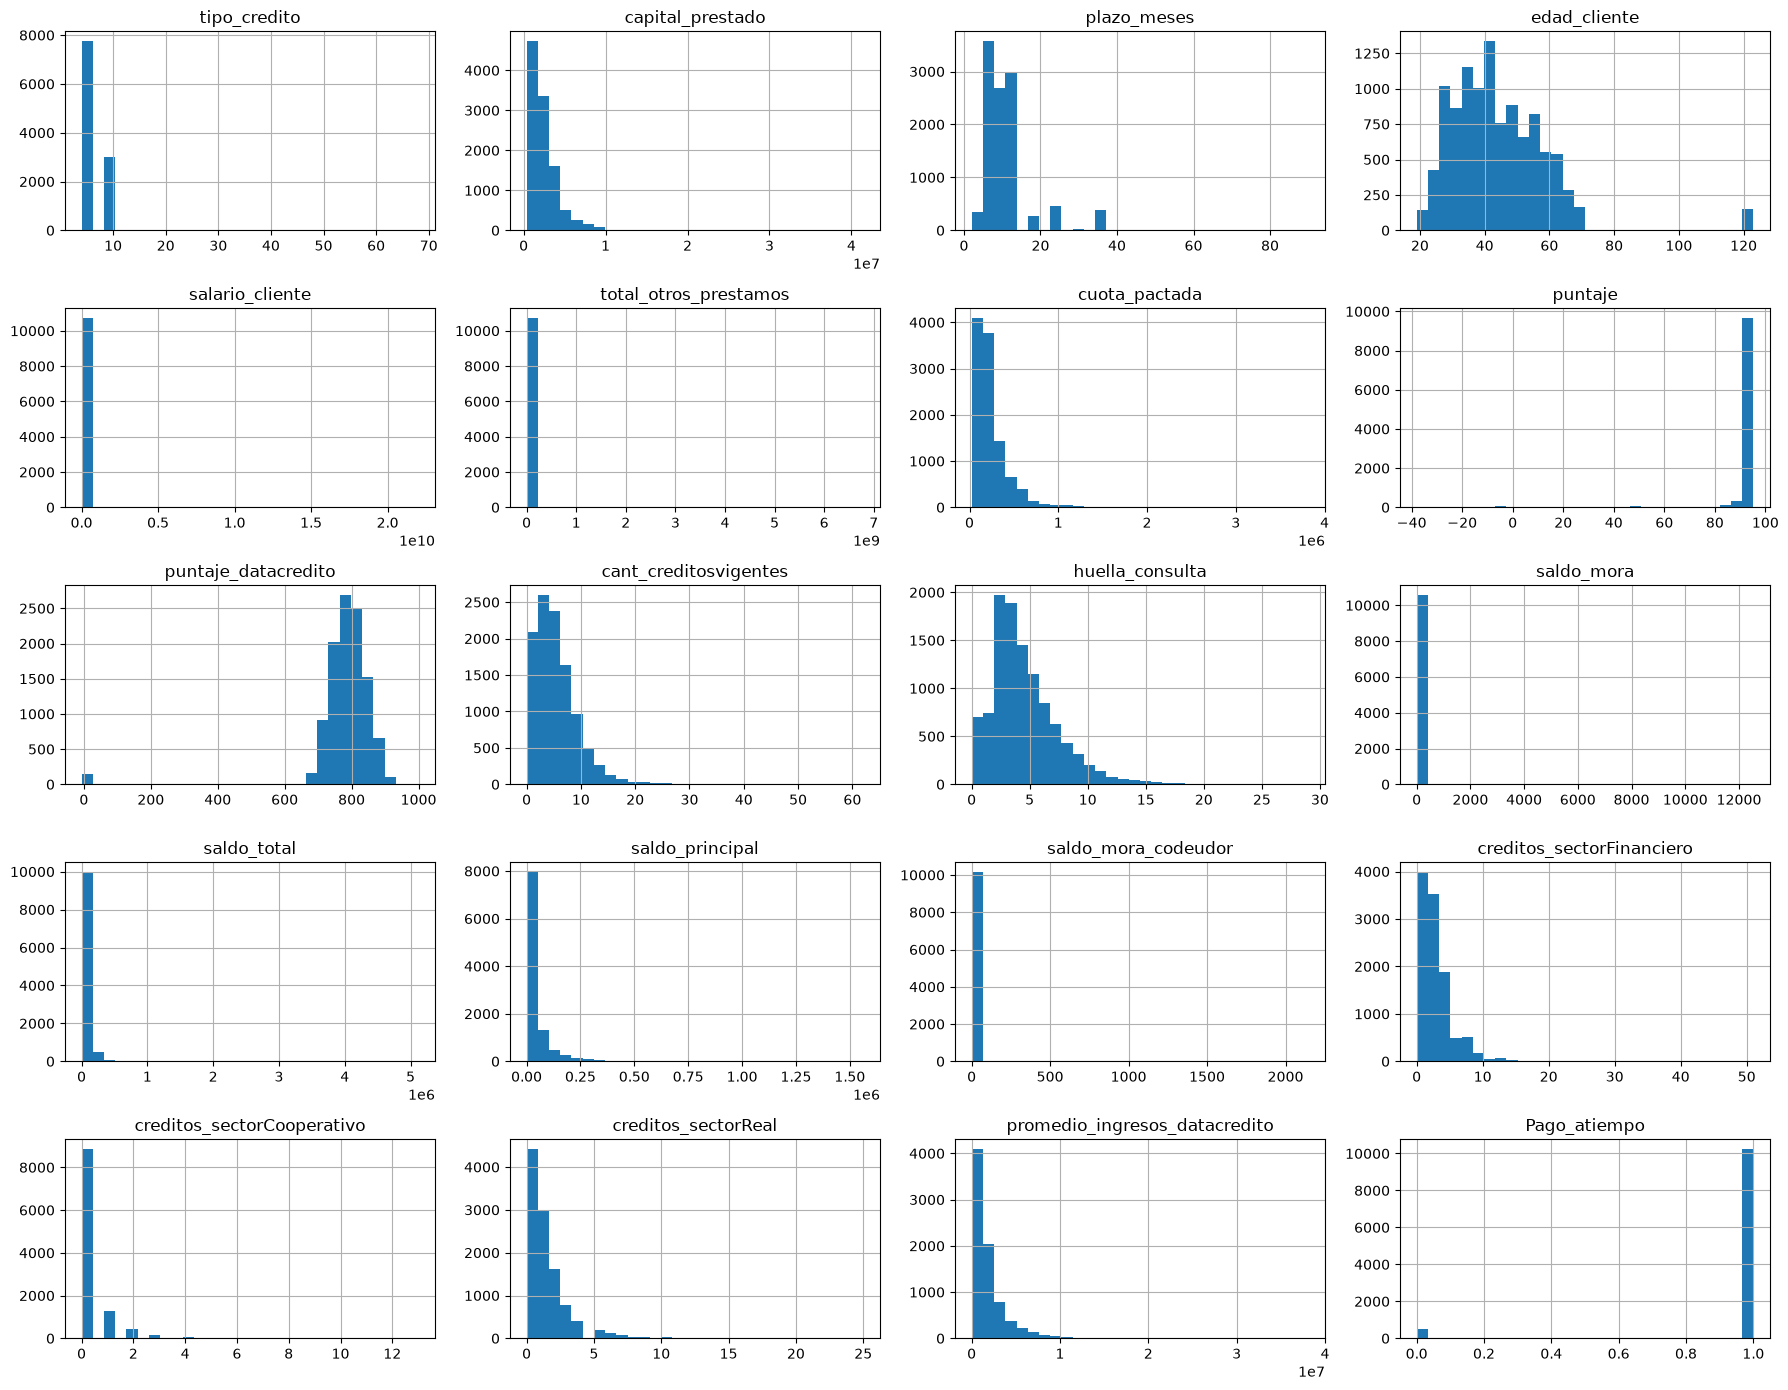

In [20]:
df[numericas].hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

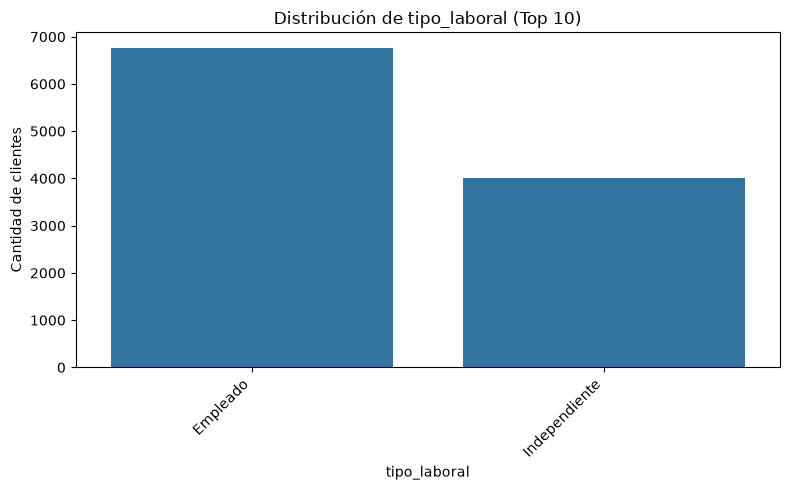

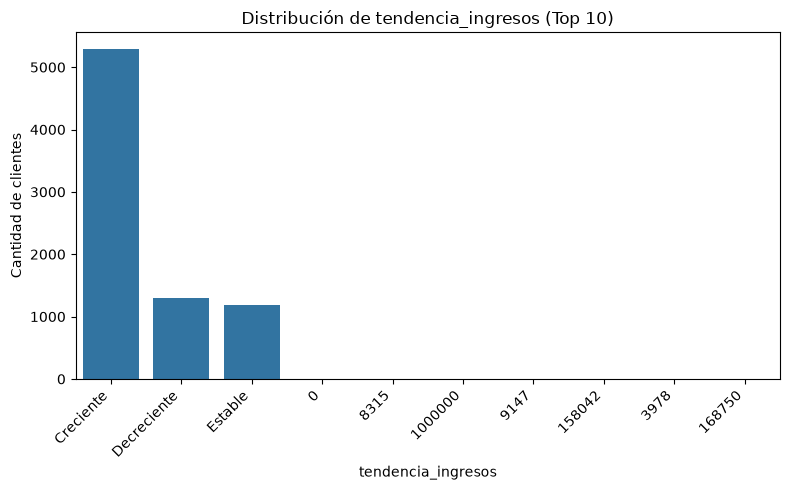

In [21]:
for col in categoricas:
    plt.figure(figsize=(8,5))
    top_categorias = df[col].value_counts().nlargest(10)
    sns.barplot(x=top_categorias.index, y=top_categorias.values)
    plt.title(f'Distribución de {col} (Top 10)')
    plt.xlabel(col)
    plt.ylabel('Cantidad de clientes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [22]:
df['tendencia_ingresos'].value_counts()

tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
22832             1
209090            1
5697              1
10808             1
-288              1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
75761             1
146918            1
1123000           1
15090             1
4250635           1
22363             1
-101368           1
86286             1
65988             1
77975             1
-224714           1
Name: count, dtype: int64

In [23]:
df['tendencia_ingresos'].value_counts()

tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
22832             1
209090            1
5697              1
10808             1
-288              1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
75761             1
146918            1
1123000           1
15090             1
4250635           1
22363             1
-101368           1
86286             1
65988             1
77975             1
-224714           1
Name: count, dtype: int64

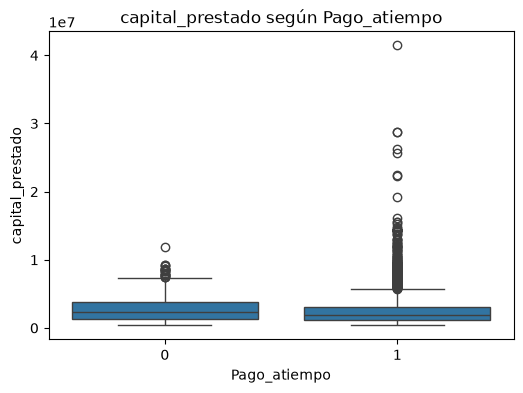

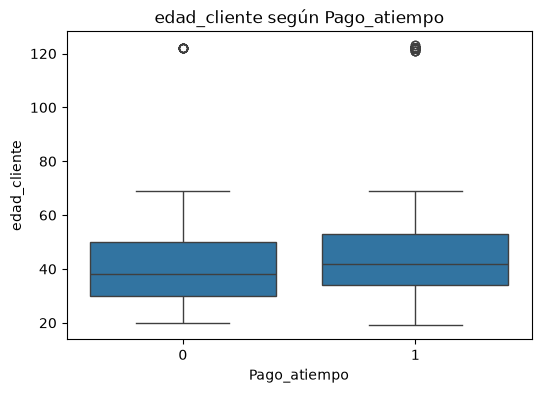

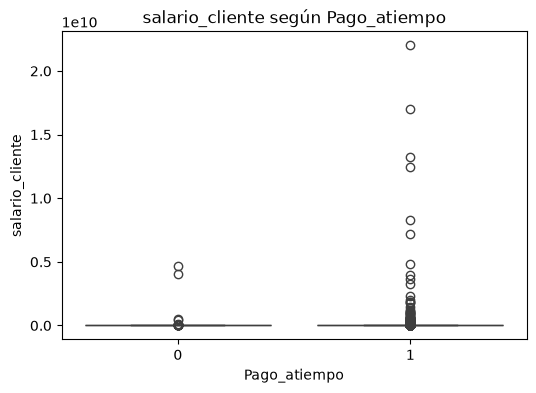

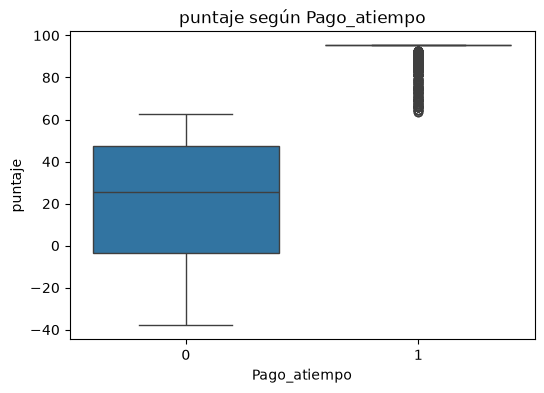

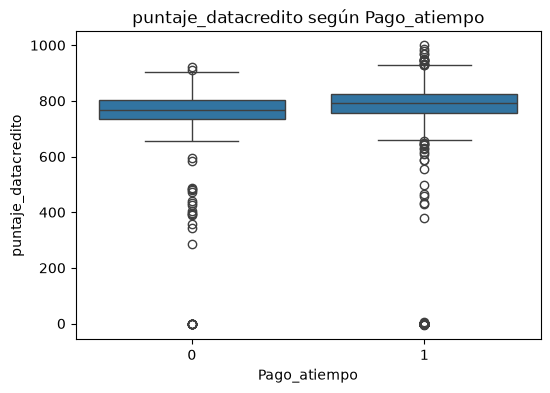

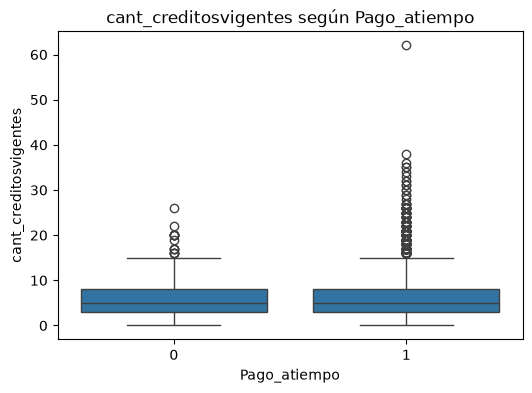

In [24]:
variables_clave = ['capital_prestado', 'edad_cliente', 'salario_cliente', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes']

for col in variables_clave:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='Pago_atiempo', y=col)
    plt.title(f'{col} según Pago_atiempo')
    plt.show()

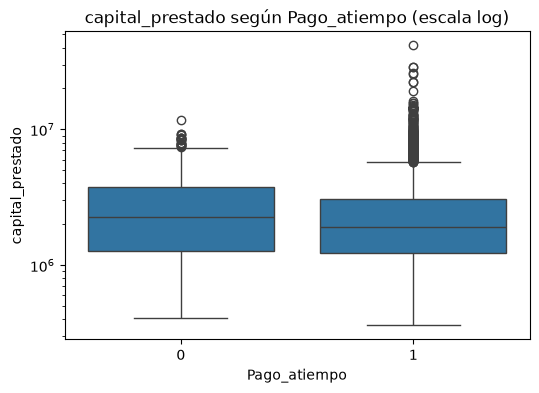

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Pago_atiempo', y='capital_prestado')
plt.yscale('log')
plt.title('capital_prestado según Pago_atiempo (escala log)')
plt.show()

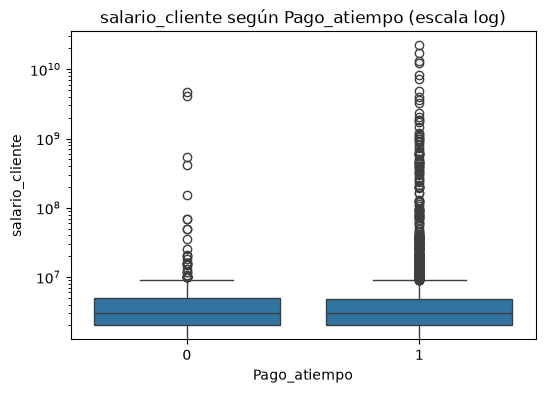

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Pago_atiempo', y='salario_cliente')
plt.yscale('log')
plt.title('salario_cliente según Pago_atiempo (escala log)')
plt.show()

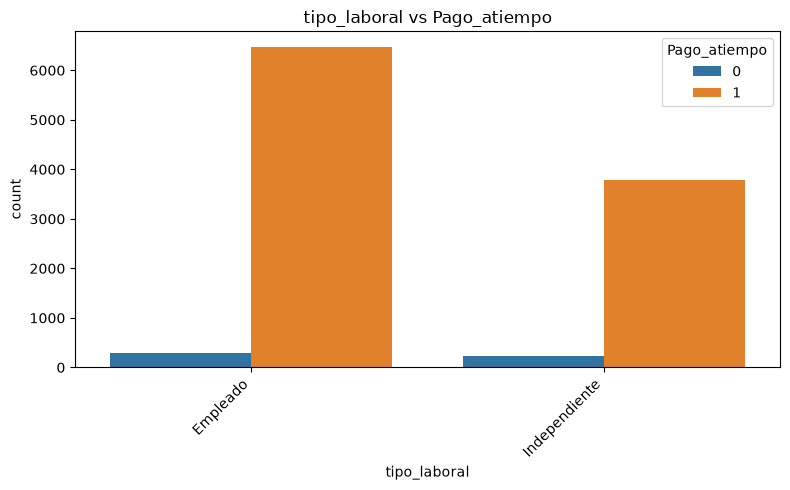

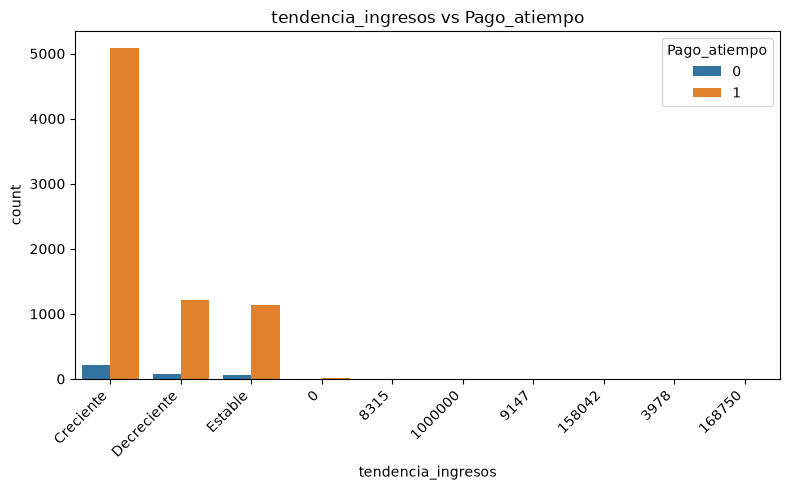

In [27]:
for col in categoricas:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col, hue='Pago_atiempo', order=df[col].value_counts().nlargest(10).index)
    plt.title(f'{col} vs Pago_atiempo')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

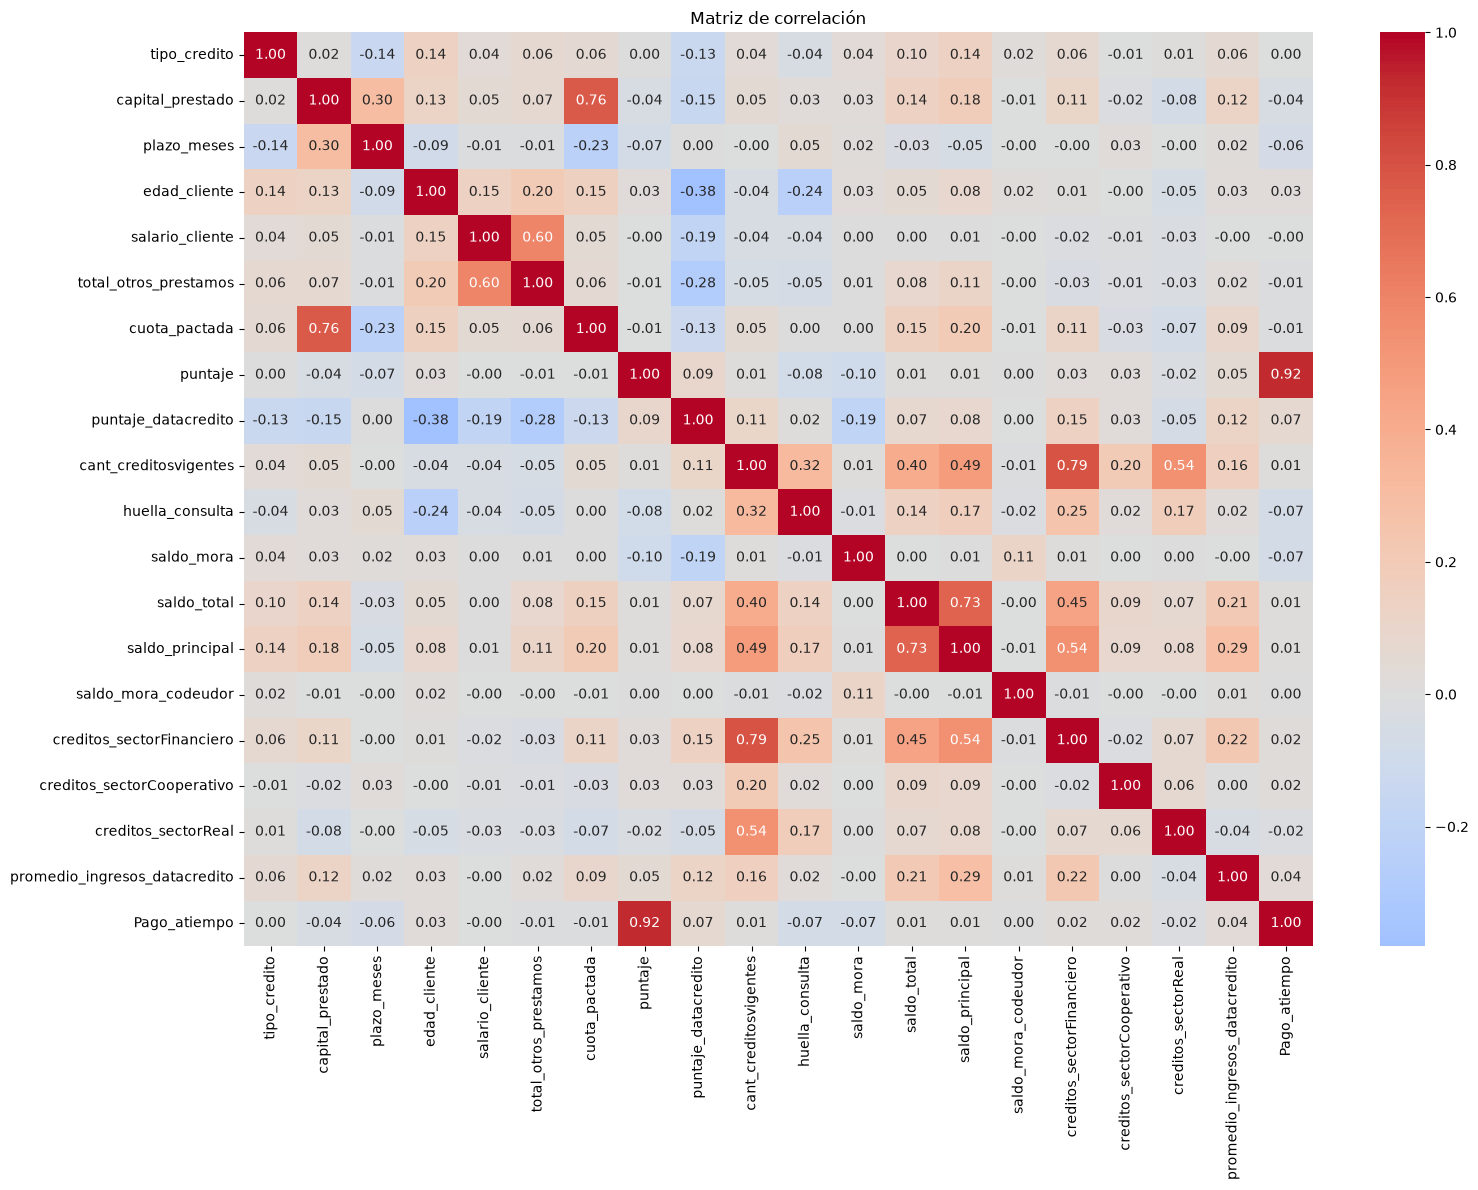

In [28]:
plt.figure(figsize=(16,12))
matriz_corr = df[numericas].corr()
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

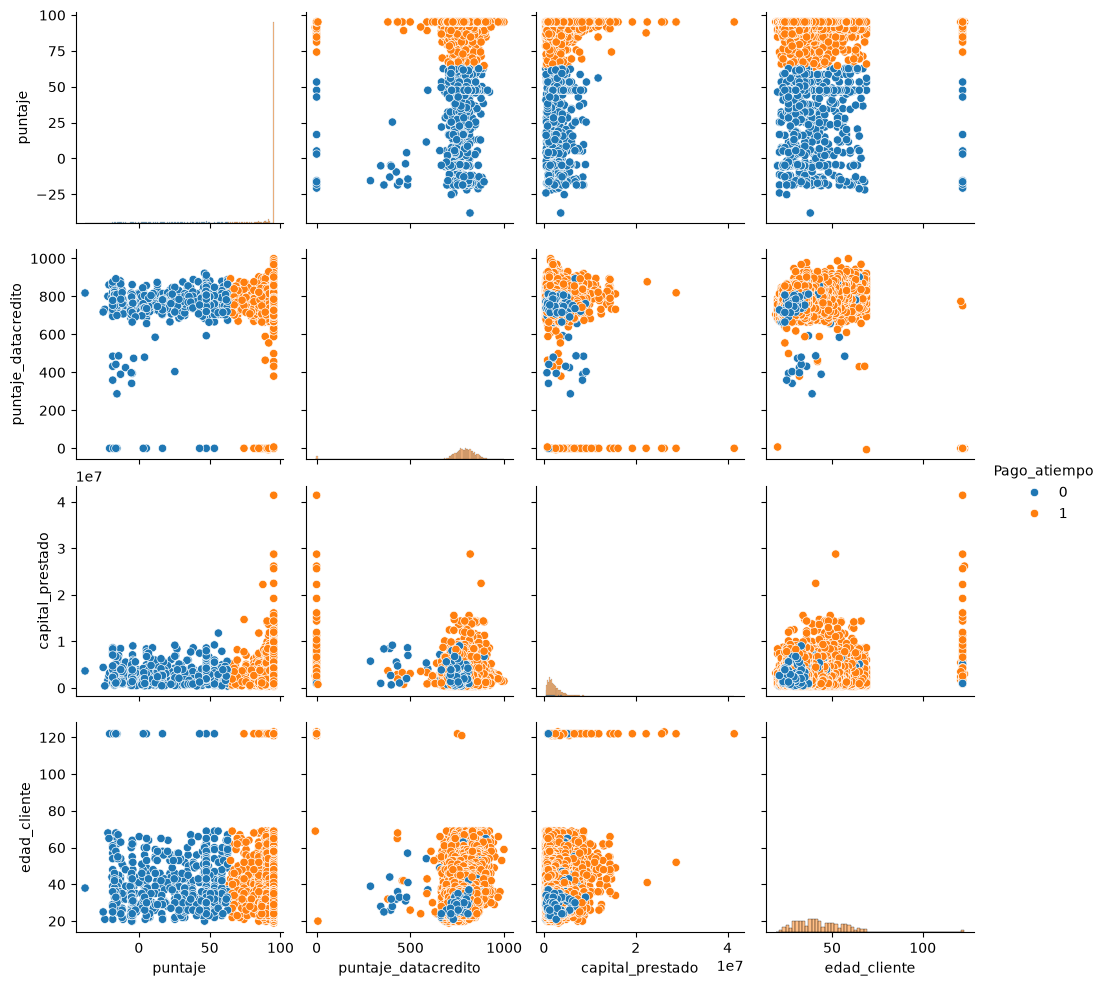

In [29]:
variables_interes = ['puntaje', 'puntaje_datacredito', 'capital_prestado', 'edad_cliente', 'Pago_atiempo']
sns.pairplot(df[variables_interes], hue='Pago_atiempo', diag_kind='hist')
plt.show()

## Conclusiones del Análisis Exploratorio (EDA)

### Calidad de datos
- Dataset de 10,763 registros y 23 columnas, sin filas duplicadas.
- Nulos relevantes: `promedio_ingresos_datacredito` y `tendencia_ingresos` (~27% cada una); nulos menores en `saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor` y `puntaje_datacredito`.
- `tendencia_ingresos` contiene ~58 registros con valores numéricos inválidos en lugar de las categorías esperadas (Creciente/Decreciente/Estable). A tratar como nulos en feature engineering.
- `edad_cliente` presenta valores imposibles (hasta 123 años).
- `puntaje` y `puntaje_datacredito` presentan valores negativos, inválidos para un score.
- `salario_cliente` y `total_otros_prestamos` presentan outliers extremos (hasta miles de millones), posibles errores de digitación.

### Variable objetivo
- `Pago_atiempo` está fuertemente desbalanceada: ~95% clase 1 (pagó a tiempo) vs ~5% clase 0. Se deberá tratar este desbalance al entrenar los modelos (SMOTE, class_weight, etc.).

### Relaciones entre variables
- Ninguna variable individual (excepto `puntaje`) muestra separación clara entre clientes que pagaron y no pagaron a tiempo en los análisis bivariados (`tipo_laboral`, `capital_prestado`, `tendencia_ingresos`).
- **`puntaje` presenta una correlación de 0.92 con `Pago_atiempo`, y el pairplot muestra una separación casi perfecta entre clases.** Esto es sospechoso de *data leakage* (posible fuga de información del futuro). Se recomienda investigar el origen de esta variable antes de usarla en el modelado.
- Se detecta multicolinealidad entre algunas variables predictoras: `capital_prestado`-`cuota_pactada` (0.76), `saldo_total`-`saldo_principal` (0.73), `cant_creditosvigentes`-`creditos_sectorFinanciero` (0.79).

### Próximos pasos (feature engineering)
- Imputar o tratar nulos según corresponda a cada variable.
- Corregir/filtrar valores fuera de rango (edad, puntajes negativos, outliers de salario).
- Decidir tratamiento de `puntaje` (posible exclusión por sospecha de leakage).
- Evaluar reducción de variables redundantes por multicolinealidad.
- Aplicar estrategia de balanceo de clases antes de entrenar modelos.